In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["TORCH_COMPILE_DISABLE"] = "1"

import matplotlib
# matplotlib.use("Agg")
%matplotlib inline

import pickle

import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

%cd /well/rittscher/users/mju725/trimodal_alignment

project_root = Path.cwd()
sys.path.insert(0, str(project_root))


import torch

from common_functions import (
    create_multisample_metadata,
    get_density_description,
    get_interaction_summary,
    load_samples,
    split_checkerboard_xenium,
)
from training_functions import load_trimodal_inputs
from trimodal_encoder import TriModalEncoder

# import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from retrieval_functions import embed_text_to_latent
from ablations_functions import (
    build_interaction_stats_table,
    build_test_patch_descriptions_and_interaction_stats,
    build_top_interaction_cohorts,
    canonical_pair,
    plot_internalization_density_panel_clean,
)

import pickle
import numpy as np

/well/rittscher/users/mju725/conda/skylake/envs/histomotif_clean/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/exafs1/well/rittscher/users/mju725/trimodal_alignment


/well/rittscher/users/mju725/conda/skylake/envs/histomotif_clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
figures_dir = "/well/rittscher/users/mju725/trimodal_alignment_objects/figures"

In [3]:
from openai import OpenAI

client = OpenAI()

In [4]:
lung_model_l1 = TriModalEncoder.load(
    "/well/rittscher/users/mju725/trimodal_alignment_objects/models/abl_studies_compayl/ablation_studies/level_1_abl_reports_lung/best.pt"
)

lung_model_l1_2 = TriModalEncoder.load(
    "/well/rittscher/users/mju725/trimodal_alignment_objects/models/abl_studies_compayl/ablation_studies/level_1_2_abl_reports_lung/best.pt"
)

lung_model_l1_2_3 = TriModalEncoder.load(
    "/well/rittscher/users/mju725/trimodal_alignment_objects/models/abl_studies_compayl/ablation_studies/level_1_2_3_abl_reports_lung/best.pt"
)

/exafs1/well/rittscher/users/mju725/trimodal_alignment/trimodal_encoder.py:297: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=devi

cuda
cuda
cuda


In [5]:
lung_dir =  "/well/rittscher/users/mju725/trimodal_alignment_objects/lung"
all_samples_metadata_lung = pd.read_csv(f"{lung_dir}/all_samples_metadata.csv") 

samples_lung = load_samples(lung_dir)
uni_embeddings_lung, cell_vectors_lung, master_gene_vectors_lung, master_text_embeddings_lung, ground_truth_openai_dict_lung = load_trimodal_inputs(samples_lung, lung_dir)

In [6]:
meta_df_lung = create_multisample_metadata(list(uni_embeddings_lung.keys()))

train_keys_lung, val_keys_lung, test_keys_lung = split_checkerboard_xenium(
        meta_df_lung, 
        n_tiles_row=5, 
        n_tiles_col=5, 
        val_frac=0.1, 
        test_frac=0.1,
        return_keys=True,
        random_state=42
)


Parsing metadata for 28362 patches...


In [7]:
outputs = build_test_patch_descriptions_and_interaction_stats(
    all_samples_metadata=all_samples_metadata_lung,
    test_keys=test_keys_lung,
    get_interaction_summary_func=get_interaction_summary,
    get_density_description_func=get_density_description,
    build_interaction_stats_table_func=build_interaction_stats_table,
    canonical_pair_func=canonical_pair,
    patch_col="patch_name",
    cell_type_col="cell_type",
    x_col="x_global",
    y_col="y_global",
    k_interactions=2,
    radius=50,
    min_a_count=5,
    min_b_count=5,
    density_threshold=0.85,
)

patches_description = outputs["patches_description"]
density_lookup = outputs["density_lookup"]
interactions_counts_sorted = outputs["interactions_counts_sorted"]
df_patch_stats = outputs["df_patch_stats"]
df_interaction_stats = outputs["df_interaction_stats"]

100%|██████████| 2783/2783 [00:52<00:00, 52.66it/s]


Missing test patches: 0


In [8]:
cohort_outputs = build_top_interaction_cohorts(
    patches_description=patches_description,
    canonical_pair_func=canonical_pair,
    min_cell_count=3,
    min_signature_count=5,
    signature_index=0,
)

cohort_a_patches = cohort_outputs["cohort_a_patches"]
cohort_b_patches = cohort_outputs["cohort_b_patches"]
target_pair = cohort_outputs["target_pair"]
patch_top_pair = cohort_outputs["patch_top_pair"]
patch_all_pairs = cohort_outputs["patch_all_pairs"]
top_signatures = cohort_outputs["top_signatures"]

Found 108 top-1 interaction niches with >= 5 patches.
Target top interaction
AT2 <-> Capillary

Cohort summary
--------------------------------------------------------------------------------
Minimum cell count per required cell: 3
True positives, Cohort A: 122
Hard negatives, Cohort B: 605


Let's examine the effect of adding spatial interactions and density on the top interaction pair.

In [9]:
def get_similarity_scores(client, model, query_text, patch_keys, uni_embeddings):
    model.eval()
    
    img_embs = np.stack([uni_embeddings[k] for k in patch_keys]).astype(np.float32)
    with torch.no_grad():
        H_img = model.embed_batch(img_embs, branch="img")
        H_text = embed_text_to_latent(client, query_text, model)
        
    scores = H_img @ H_text.T
    return scores.flatten()

In [10]:
query_interaction = "AT2 cells adjacent to capillaries."
scores_l1_a = get_similarity_scores(client, lung_model_l1, query_interaction, cohort_a_patches, uni_embeddings_lung)
scores_l1_b = get_similarity_scores(client, lung_model_l1, query_interaction, cohort_b_patches, uni_embeddings_lung)

scores_l12_a = get_similarity_scores(client, lung_model_l1_2, query_interaction, cohort_a_patches, uni_embeddings_lung)
scores_l12_b = get_similarity_scores(client, lung_model_l1_2, query_interaction, cohort_b_patches, uni_embeddings_lung)

In [11]:
def get_dense_vs_control_cohort(density_lookup, cohort_a_interaction_patches, density_threshold_dense, density_threshold_nondense):
    density_threshold_dense = 0.85
    density_threshold_nondense = 0.60

    cohort_a_dense = []
    cohort_a_nondense = []

    for patch_key in cohort_a_interaction_patches:
        density = density_lookup[patch_key]["percentile"]

        if density >= density_threshold_dense:
            cohort_a_dense.append(patch_key)
        elif density <= density_threshold_nondense:
            cohort_a_nondense.append(patch_key)

    print(f"Dense interaction-positive patches: {len(cohort_a_dense)}")
    print(f"Non-dense interaction-positive patches: {len(cohort_a_nondense)}")
    
    return cohort_a_dense, cohort_a_nondense

In [12]:
cohort_a_dense, cohort_a_nondense = get_dense_vs_control_cohort(density_lookup, cohort_a_patches, 0.85, 0.6)

Dense interaction-positive patches: 10
Non-dense interaction-positive patches: 61


In [13]:
query_density = "High-density tissue region where AT2 cells are adjacent to capillaries."
scores_l12_dense = get_similarity_scores(client, lung_model_l1_2, query_density, cohort_a_dense, uni_embeddings_lung)
scores_l12_nondense = get_similarity_scores(client, lung_model_l1_2, query_density, cohort_a_nondense, uni_embeddings_lung)

scores_l123_dense = get_similarity_scores(client, lung_model_l1_2_3, query_density, cohort_a_dense, uni_embeddings_lung)
scores_l123_nondense = get_similarity_scores(client, lung_model_l1_2_3, query_density, cohort_a_nondense, uni_embeddings_lung)

Holding the interaction fixed, the L1+L2 model does not retrieve dense interaction-positive patches more strongly than non-dense ones. After adding Level 3 density supervision, the L1+L2+L3 model shifts high-density patches to higher similarity and non-dense patches to lower similarity.

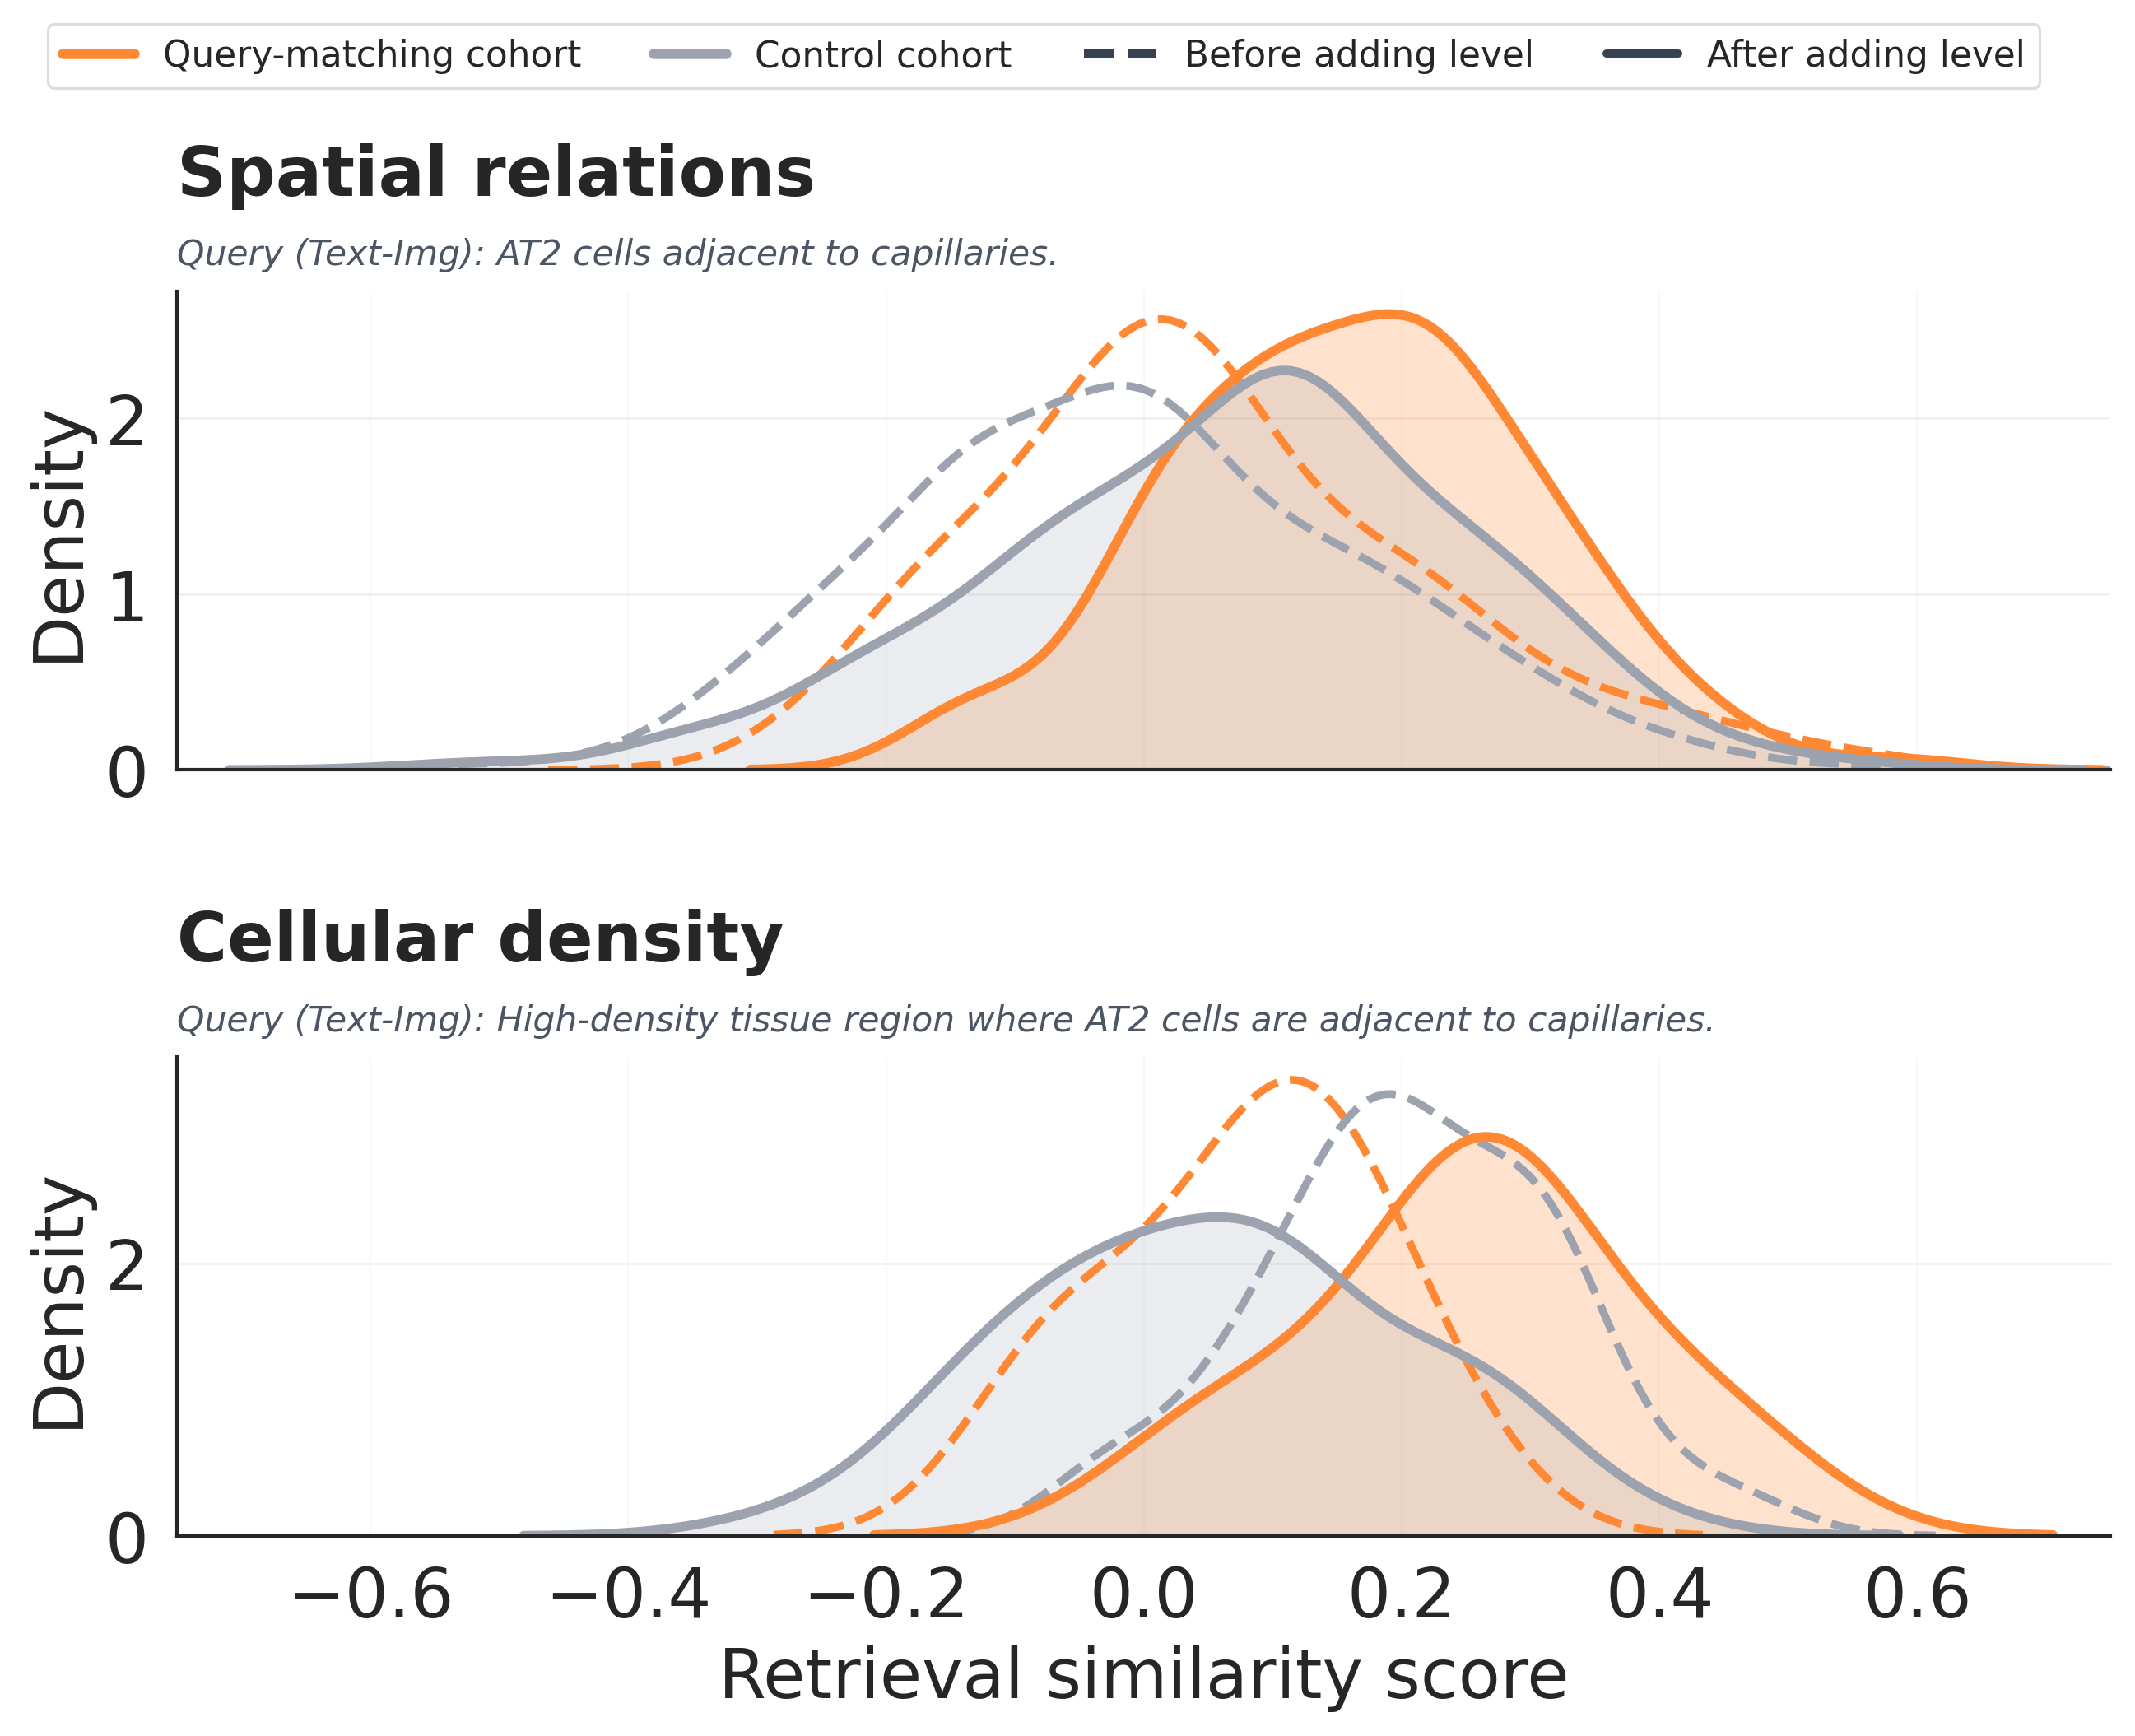

In [17]:
fig, axes = plot_internalization_density_panel_clean(
    scores_l1_a=scores_l1_a,
    scores_l1_b=scores_l1_b,
    scores_l12_a=scores_l12_a,
    scores_l12_b=scores_l12_b,
    scores_l12_dense=scores_l12_dense,
    scores_l12_nondense=scores_l12_nondense,
    scores_l123_dense=scores_l123_dense,
    scores_l123_nondense=scores_l123_nondense,
    figures_dir=figures_dir,
    out_name="internalisation_of_levels_final",
    query_interaction=query_interaction,
    query_density=query_density,
    xlim=(-0.75, 0.75),
    bw_adjust=1.0,
    figsize=(9, 7.0),
)